# US Billionaire Wealth: Election Day 2024 vs. Today

Two data points per person: net worth at Election Day (Nov 5, 2024) and today (mid-June 2026).  
All figures in USD billions. Election-day values are approximate.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# name -> (net worth Nov 5 2024, net worth today), USD billions
data = {
    "Elon Musk":       (264, 1260),
    "Larry Page":      (150,  281),
    "Sergey Brin":     (142,  261),
    "Jeff Bezos":      (206,  249),
    "Larry Ellison":   (175,  201),
    "Michael Dell":    (118,  165),
    "Mark Zuckerberg": (201,  187),
}

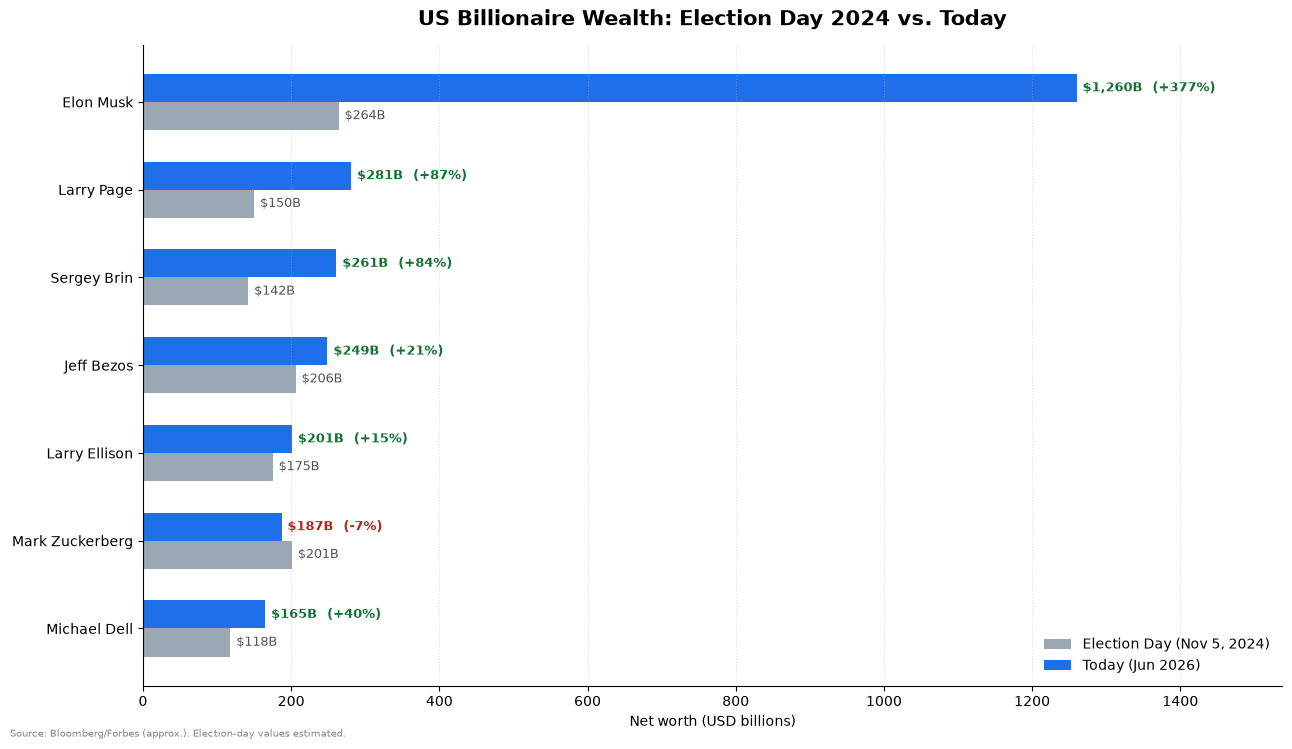

In [3]:
order = sorted(data.items(), key=lambda kv: kv[1][1], reverse=True)
names  = [k for k, _ in order]
before = np.array([v[0] for _, v in order], dtype=float)
now    = np.array([v[1] for _, v in order], dtype=float)
pct    = (now - before) / before * 100.0

y     = np.arange(len(names))
bar_h = 0.32

fig, ax = plt.subplots(figsize=(13, 7.5))

bars_before = ax.barh(y + bar_h / 2, before, height=bar_h,
                      label="Election Day (Nov 5, 2024)", color="#9aa7b4")
bars_now    = ax.barh(y - bar_h / 2, now, height=bar_h,
                      label="Today (Jun 2026)", color="#1f6feb")

for b in bars_before:
    w = b.get_width()
    ax.text(w + 8, b.get_y() + b.get_height() / 2,
            f"${w:,.0f}B", va="center", ha="left", fontsize=9, color="#555")

for b, p in zip(bars_now, pct):
    w = b.get_width()
    sign  = "+" if p >= 0 else ""
    color = "#137333" if p >= 0 else "#b3261e"
    ax.text(w + 8, b.get_y() + b.get_height() / 2,
            f"${w:,.0f}B  ({sign}{p:.0f}%)",
            va="center", ha="left", fontsize=9, fontweight="bold", color=color)

ax.set_yticks(y)
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel("Net worth (USD billions)")
ax.set_title("US Billionaire Wealth: Election Day 2024 vs. Today",
             fontsize=15, fontweight="bold", pad=14)
ax.set_xlim(0, max(now) * 1.22)
ax.legend(loc="lower right", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle=":", alpha=0.4)

fig.text(0.01, 0.01,
         "Source: Bloomberg/Forbes (approx.). Election-day values estimated.",
         fontsize=7, color="#888")

plt.tight_layout()
plt.show()